# 04-Finance Tutorial- Pricing European Put Options
### Modified for Quantum Rings toolkit for Qiskit 2.x

In [1]:
# This tutorial is from:
# https://qiskit-community.github.io/qiskit-finance/tutorials/04_european_put_option_pricing.html

# Modified for use with Quantum Rings toolkit

In [2]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#

import os

my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [3]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction
#from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import LogNormalDistribution

In [4]:
from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrSamplerV2 as Sampler

qr_services = QrRuntimeService(name = my_name, token = my_token)
qr_backend = qr_services.backend(name = my_backend, precision = "single")

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(backend=qr_backend)

In [5]:
# number of qubits to represent the uncertainty
num_uncertainty_qubits = 3

# parameters for considered random distribution
S = 2.0  # initial spot price
vol = 0.4  # volatility of 40%
r = 0.05  # annual interest rate of 4%
T = 40 / 365  # 40 days to maturity

# resulting parameters for log-normal distribution
mu = (r - 0.5 * vol**2) * T + np.log(S)
sigma = vol * np.sqrt(T)
mean = np.exp(mu + sigma**2 / 2)
variance = (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)
stddev = np.sqrt(variance)

# lowest and highest value considered for the spot price; in between, an equidistant discretization is considered.
low = np.maximum(0, mean - 3 * stddev)
high = mean + 3 * stddev

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
uncertainty_model = LogNormalDistribution(
    num_uncertainty_qubits, mu=mu, sigma=sigma**2, bounds=(low, high)
)

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\%'
C:\Users\vkasi\AppData\Local\Temp\ipykernel_5868\3596282585.py:8: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
C:\Users\vkasi\AppData\Local\Temp\ipykernel_5868\3596282585.py:9: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel("Probability ($\%$)", size=15)


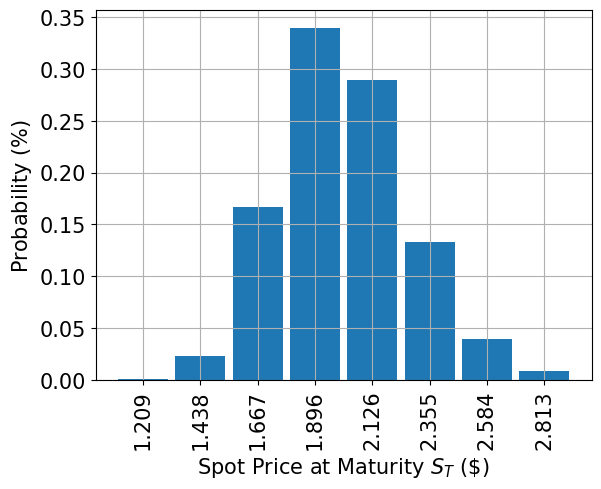

In [6]:
# plot probability distribution
x = uncertainty_model.values
y = uncertainty_model.probabilities
plt.bar(x, y, width=0.2)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.grid()
plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
plt.ylabel("Probability ($\%$)", size=15)
plt.show()


In [7]:
# set the strike price (should be within the low and the high value of the uncertainty)
strike_price = 2.126

# set the approximation scaling for the payoff function
rescaling_factor = 0.25

# setup piecewise linear objective fcuntion
breakpoints = [low, strike_price]
slopes = [-1, 0]
offsets = [strike_price - low, 0]
f_min = 0
f_max = strike_price - low
european_put_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
    rescaling_factor=rescaling_factor,
)

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
european_put = european_put_objective.compose(uncertainty_model, front=True)

C:\Users\vkasi\AppData\Local\Temp\ipykernel_5868\2114397473.py:13: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  european_put_objective = LinearAmplitudeFunction(


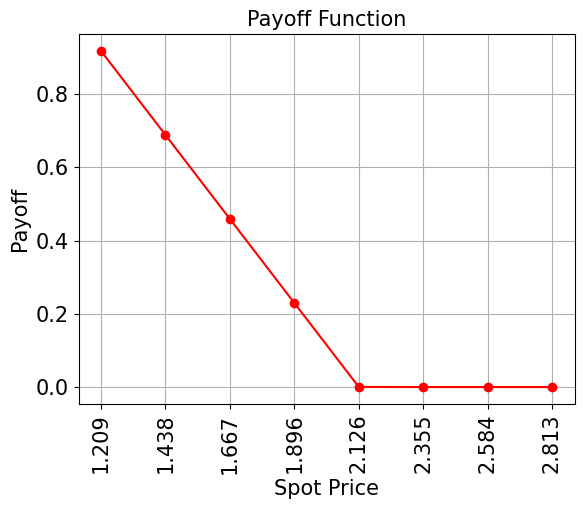

In [8]:
# plot exact payoff function (evaluated on the grid of the uncertainty model)
x = uncertainty_model.values
y = np.maximum(0, strike_price - x)
plt.plot(x, y, "ro-")
plt.grid()
plt.title("Payoff Function", size=15)
plt.xlabel("Spot Price", size=15)
plt.ylabel("Payoff", size=15)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.show()

In [9]:
# evaluate exact expected value (normalized to the [0, 1] interval)
exact_value = np.dot(uncertainty_model.probabilities, y)
exact_delta = -sum(uncertainty_model.probabilities[x <= strike_price])
print("exact expected value:\t%.4f" % exact_value)
print("exact delta value:   \t%.4f" % exact_delta)

exact expected value:	0.1709
exact delta value:   	-0.8193


In [10]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=european_put,
    objective_qubits=[num_uncertainty_qubits],
    post_processing=european_put_objective.post_processing,
)
# construct amplitude estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(run_options={"shots": 100, "seed": 75})
)

In [11]:
result = ae.estimate(problem)

In [12]:
conf_int = np.array(result.confidence_interval_processed)
print("Exact value:        \t%.4f" % exact_value)
print("Estimated value:    \t%.4f" % (result.estimation_processed))
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	0.1709
Estimated value:    	0.1768
Confidence interval:	[0.1559, 0.1978]


In [13]:
# Example Output:
# Exact value:        	0.1709
# Estimated value:    	0.1861
# Confidence interval:	[0.1720, 0.2002]

In [14]:
# setup piecewise linear objective fcuntion
breakpoints = [low, strike_price]
slopes = [0, 0]
offsets = [1, 0]
f_min = 0
f_max = 1

european_put_delta_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
)

# construct circuit for payoff function
european_put_delta = european_put_delta_objective.compose(uncertainty_model, front=True)

# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=european_put_delta, objective_qubits=[num_uncertainty_qubits]
)
# construct amplitude estimation
ae_delta = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(run_options={"shots": 100, "seed": 75})
)

C:\Users\vkasi\AppData\Local\Temp\ipykernel_5868\2152573025.py:8: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  european_put_delta_objective = LinearAmplitudeFunction(


In [15]:
result_delta = ae_delta.estimate(problem)

In [16]:
conf_int = -np.array(result_delta.confidence_interval)[::-1]
print("Exact delta:    \t%.4f" % exact_delta)
print("Estimated value: \t%.4f" % -result_delta.estimation)
print("Confidence interval: \t[%.4f, %.4f]" % tuple(conf_int))

Exact delta:    	-0.8193
Estimated value: 	-0.8228
Confidence interval: 	[-0.8291, -0.8166]


In [17]:
# Example Output:
# Exact delta:    	-0.8193
# Estimated value: 	-0.8200
# Confidence interval: 	[-0.8239, -0.8160]

In [18]:
import tutorial_magics

%qiskit_version_table
%quantumrings_version_table
%qiskit_copyright

Software,Version
QuantumRingsLib,0.11.0
quantumrings-toolkit-qiskit,0.1.10
